## Q1

In [1]:
import torch

def softmax(X):
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdims=True)
    return X_exp / partition

In [2]:
# Q1.1: an input has a value of 100
X = torch.tensor([[100.0, 0.0, 0.0]])
softmax(X)

tensor([[nan, 0., 0.]])

In [3]:
# Q1.2: the largest of all inputs is smaller than -100
X = torch.tensor([[-150.0, -200.0, -250.0]])
softmax(X)

tensor([[nan, nan, nan]])

In [4]:
# Q1.3: fix — subtract the row-wise max before exp.
def stable_softmax(X):
    X = X - X.max(1, keepdims=True).values
    X_exp = torch.exp(X)
    partition = X_exp.sum(1, keepdims=True)
    return X_exp / partition

print(stable_softmax(torch.tensor([[100.0, 0.0, 0.0]])))
print(stable_softmax(torch.tensor([[-150.0, -200.0, -250.0]])))

tensor([[1.0000e+00, 3.7835e-44, 3.7835e-44]])
tensor([[1.0000e+00, 1.9287e-22, 3.7835e-44]])


## Q2

Source of the waste: Elements are destined to be multiplied by 0, but their log values are calculated.

In [5]:
# section's version: index out the probability of the true class
def cross_entropy_gather(y_hat, y):
    return -torch.log(y_hat[range(len(y_hat)), y]).mean()

# by definition: sum_i y_i * log(y_hat_i) with one-hot y
def cross_entropy_onehot(y_hat, y):
    Y = torch.nn.functional.one_hot(y, num_classes=y_hat.shape[1]).float()
    return -(Y * torch.log(y_hat)).sum(1).mean()

# correctness check
y_hat = stable_softmax(torch.randn(256, 10))
y = torch.randint(0, 10, (256,))
cross_entropy_gather(y_hat, y), cross_entropy_onehot(y_hat, y)

(tensor(2.7329), tensor(2.7329))

In [6]:
import time

def bench(f, *args, reps=200):
    f(*args)  # warmup
    t0 = time.perf_counter()
    for _ in range(reps):
        f(*args)
    return (time.perf_counter() - t0) / reps * 1e3  # ms/call

for n, k in [(256, 10), (256, 10000), (1024, 10000)]:
    y_hat = stable_softmax(torch.randn(n, k))
    y = torch.randint(0, k, (n,))
    tg = bench(cross_entropy_gather, y_hat, y)
    to = bench(cross_entropy_onehot, y_hat, y)
    print(f"n={n:5d} k={k:5d}: gather {tg:8.4f} ms | one-hot {to:8.4f} ms | {to/tg:5.1f}x slower")

n=  256 k=   10: gather   0.0872 ms | one-hot   0.0511 ms |   0.6x slower


n=  256 k=10000: gather   0.0819 ms | one-hot   2.9736 ms |  36.3x slower


n= 1024 k=10000: gather   0.2950 ms | one-hot  11.6988 ms |  39.7x slower


## Q3

No, for medical field, a false negative is far worse than a false positive.

## Q5

In [7]:
import torchvision
import matplotlib.pyplot as plt

# load Fashion-MNIST into memory once (flattened, scaled to [0,1])
tr = torchvision.datasets.FashionMNIST(root="../data", train=True, download=True)
va = torchvision.datasets.FashionMNIST(root="../data", train=False, download=True)
X_train, y_train = tr.data.reshape(-1, 784).float() / 255, tr.targets
X_val, y_val = va.data.reshape(-1, 784).float() / 255, va.targets

# scratch softmax regression, reusing stable_softmax / cross_entropy_gather from Q1-Q2
def train_softmax(lr, batch_size, num_epochs=10, seed=0):
    torch.manual_seed(seed)
    W = torch.normal(0, 0.01, (784, 10), requires_grad=True)
    b = torch.zeros(10, requires_grad=True)
    n = len(X_train)
    train_loss, val_loss = [], []
    for _ in range(num_epochs):
        perm, total = torch.randperm(n), 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            loss = cross_entropy_gather(stable_softmax(X_train[idx] @ W + b), y_train[idx])
            loss.backward()
            with torch.no_grad():
                W -= lr * W.grad; b -= lr * b.grad
                W.grad.zero_(); b.grad.zero_()
            total += loss.item() * len(idx)
        train_loss.append(total / n)
        with torch.no_grad():
            val_loss.append(cross_entropy_gather(stable_softmax(X_val @ W + b), y_val).item())
    return train_loss, val_loss

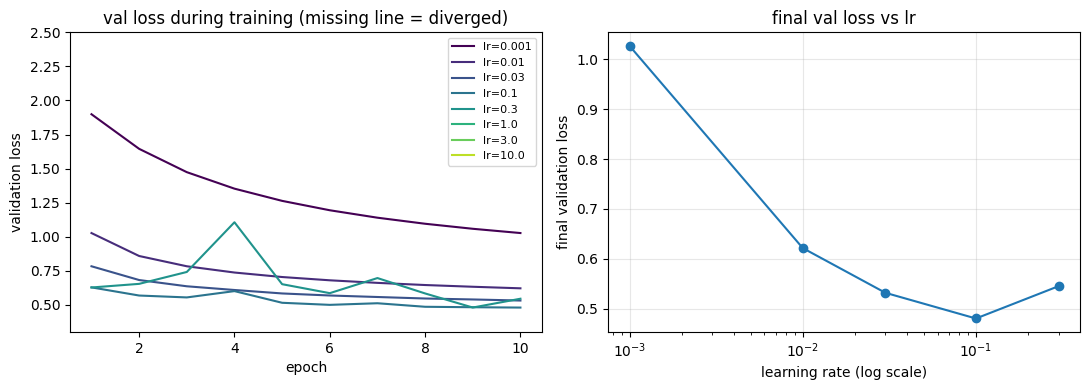

In [8]:
# Q5.1: validation loss vs learning rate (batch_size=256, 10 epochs)
lrs = [0.001, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]
lr_results = {lr: train_softmax(lr, batch_size=256) for lr in lrs}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = plt.cm.viridis(torch.linspace(0, 0.9, len(lrs)).numpy())
for c, lr in zip(colors, lrs):
    axes[0].plot(range(1, 11), lr_results[lr][1], color=c, label=f"lr={lr}")
axes[0].set(xlabel="epoch", ylabel="validation loss", ylim=(0.3, 2.5),
            title="val loss during training (missing line = diverged)")
axes[0].legend(fontsize=8)
axes[1].plot(lrs, [lr_results[lr][1][-1] for lr in lrs], "o-")
axes[1].set(xscale="log", xlabel="learning rate (log scale)",
            ylabel="final validation loss", title="final val loss vs lr")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

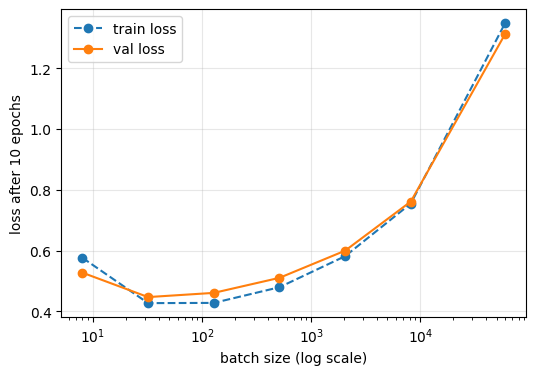

In [9]:
# Q5.2: effect of minibatch size (lr=0.1, 10 epochs each)
bss = [8, 32, 128, 512, 2048, 8192, 60000]
bs_results = {bs: train_softmax(0.1, batch_size=bs) for bs in bss}

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(bss, [bs_results[bs][0][-1] for bs in bss], "o--", label="train loss")
ax.plot(bss, [bs_results[bs][1][-1] for bs in bss], "o-", label="val loss")
ax.set(xscale="log", xlabel="batch size (log scale)", ylabel="loss after 10 epochs")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Q5.1** Val loss vs lr is U-shaped. lr=0.001 converges too slowly (val 1.03 after 10 epochs); lr=0.1 is best (0.48); lr=0.3 already oscillates (spikes to 1.1 mid-training); lr ≥ 1.0 diverges to nan in the very first epoch.

**Q5.2** With lr=0.1 and 10 epochs fixed, the sweet spot is bs = 32~128 (val ≈ 0.45). Large batches hurt because updates per epoch shrink: visible from bs ≈ 512, bad at 2048 (0.60), full batch 60000 barely trains (1.31, only 10 updates total). At the small end bs=8 is slightly worse (0.53): gradient noise is too high for this lr. Train and val loss move together in all cases — this is an optimization effect, not overfitting.